<a href="https://colab.research.google.com/github/Chuxian-Chen/Fairness-Loan/blob/main/Results_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RESULTS_DIR = 'Saved_Results'
TABLE_4_6 = os.path.join(RESULTS_DIR, 'Table_4_6_Performance.csv')
TABLE_4_7 = os.path.join(RESULTS_DIR, 'Table_4_7_SPD_Runs.csv')
TABLE_4_8 = os.path.join(RESULTS_DIR, 'Table_4_8_Significance.csv')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.unicode_minus'] = False

for f in [TABLE_4_6, TABLE_4_7, TABLE_4_8]:
    if not os.path.exists(f):
        print(f"Error: can not find file {f}")

df_perf = pd.read_csv(TABLE_4_6)
df_runs = pd.read_csv(TABLE_4_7)
df_sig = pd.read_csv(TABLE_4_8)

print("Successfully loaded results, start process results charts")

Successfully loaded results, start process results charts


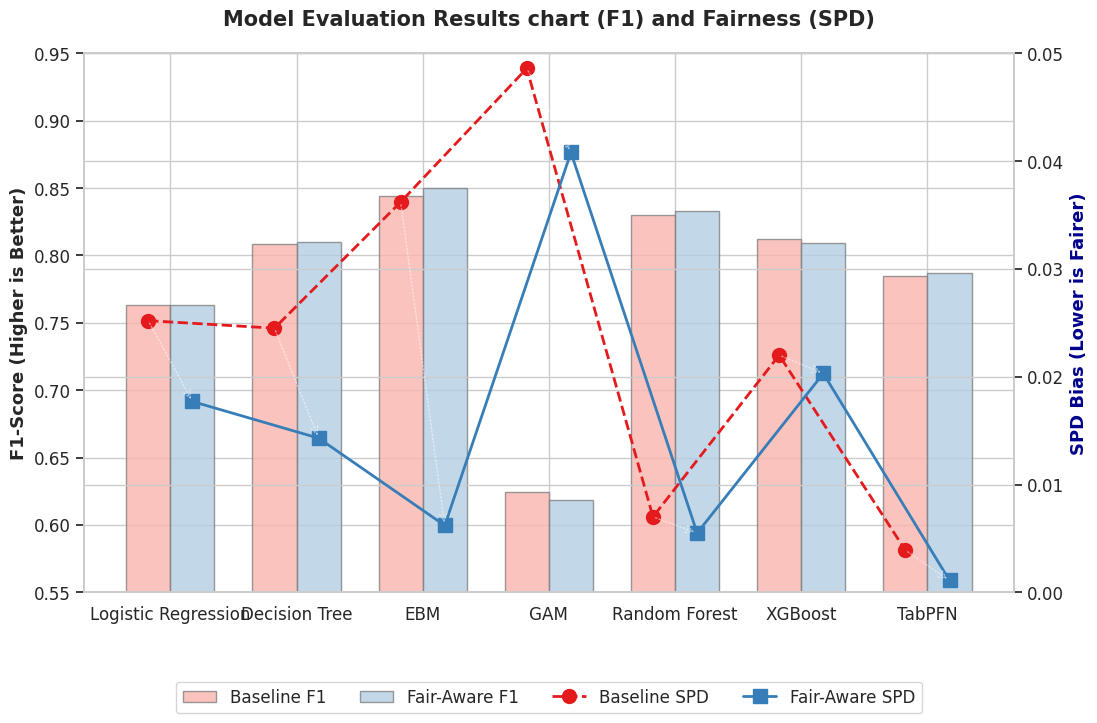

Finish Model Evaluation Results chart


In [ ]:
# Model Evaluation Results chart
fig1, ax1_left = plt.subplots(figsize=(12, 7))
algorithms = df_perf['Algorithm'].unique()
x = np.arange(len(algorithms))
width = 0.35

# F1-Score (bar chart)
base_f1 = [df_perf[(df_perf['Algorithm'] == alg) & (df_perf['Strategy'] == 'Baseline')]['F1 Score'].values[0] for
           alg in algorithms]
fair_f1 = [df_perf[(df_perf['Algorithm'] == alg) & (df_perf['Strategy'] == 'Fairness-Aware')]['F1 Score'].values[0]
           for alg in algorithms]

ax1_left.bar(x - width / 2, base_f1, width, label='Baseline F1', color='#fbb4ae', edgecolor='gray', alpha=0.8)
ax1_left.bar(x + width / 2, fair_f1, width, label='Fair-Aware F1', color='#b3cde3', edgecolor='gray', alpha=0.8)

ax1_left.set_ylabel('F1-Score (Higher is Better)', fontsize=13, fontweight='bold')
ax1_left.set_ylim(0.55, 0.95)
ax1_left.set_xticks(x)
ax1_left.set_xticklabels(algorithms)

# SPD Bias (Line chart)
ax1_right = ax1_left.twinx()
base_spd = [df_perf[(df_perf['Algorithm'] == alg) & (df_perf['Strategy'] == 'Baseline')]['SPD (Bias)'].values[0] for
            alg in algorithms]
fair_spd = [
    df_perf[(df_perf['Algorithm'] == alg) & (df_perf['Strategy'] == 'Fairness-Aware')]['SPD (Bias)'].values[0] for
    alg in algorithms]

ax1_right.plot(x - width / 2, base_spd, 'o--', color='#e41a1c', markersize=10, linewidth=2, label='Baseline SPD')
ax1_right.plot(x + width / 2, fair_spd, 's-', color='#377eb8', markersize=10, linewidth=2, label='Fair-Aware SPD')

# Draw descending guide line
for i in range(len(algorithms)):
    ax1_right.annotate('', xy=(x[i] + width / 2, fair_spd[i]), xytext=(x[i] - width / 2, base_spd[i]),
                       arrowprops=dict(facecolor='black', arrowstyle='->', linestyle=':', alpha=0.5))

ax1_right.set_ylabel('SPD Bias (Lower is Fairer)', fontsize=13, color='darkblue', fontweight='bold')
ax1_right.set_ylim(0, 0.05)

# Merged Legend
h1, l1 = ax1_left.get_legend_handles_labels()
h2, l2 = ax1_right.get_legend_handles_labels()
ax1_left.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.title('Model Evaluation Results chart (F1) and Fairness (SPD)', fontsize=15,
          pad=20, fontweight='bold')
plt.savefig(os.path.join(RESULTS_DIR, 'Figure_Model Evaluation Results.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Finish Model Evaluation Results chart")

/tmp/ipykernel_4964/1859193634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_runs_melted, x='Model', y='SPD', palette='vlag', showfliers=False)


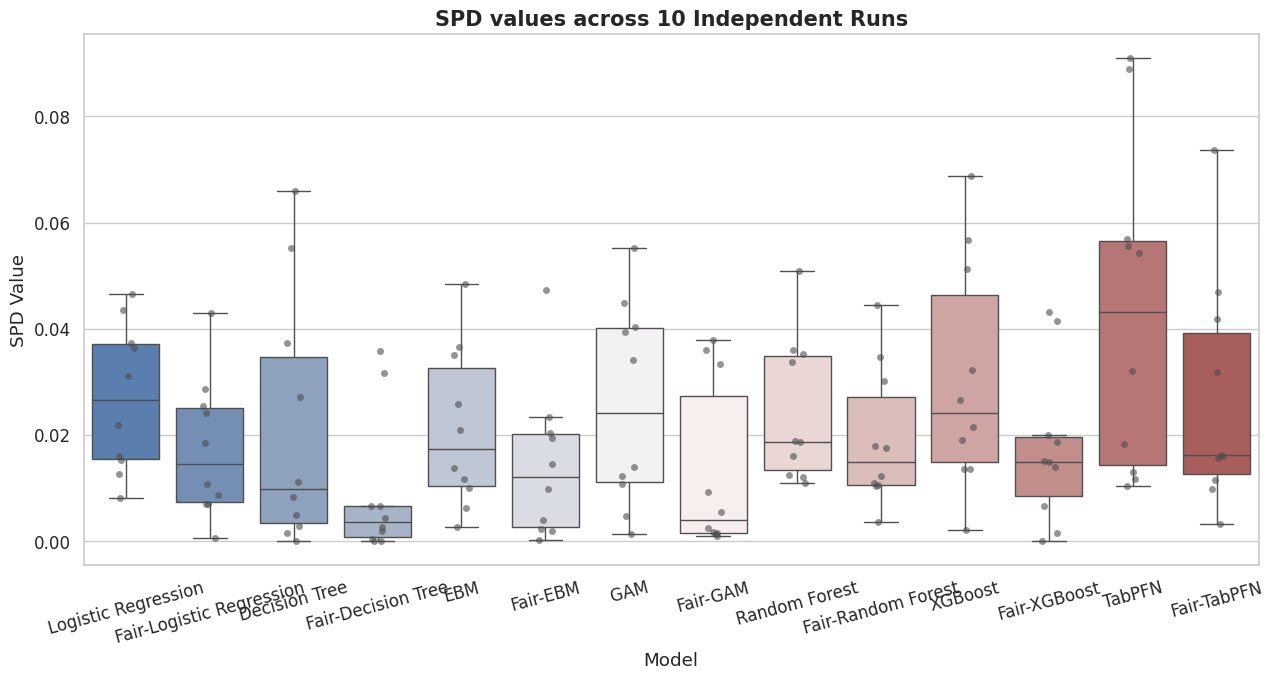

Finish Distribution of data from 10 SPD experiments chart


In [ ]:
# Distribution of data from 10 SPD experiments chart
plt.figure(figsize=(13, 7))
run_cols = [c for c in df_runs.columns if 'Run' in c]
df_runs_melted = df_runs.melt(id_vars='Model', value_vars=run_cols, var_name='Run', value_name='SPD')

sns.boxplot(data=df_runs_melted, x='Model', y='SPD', palette='vlag', showfliers=False)
sns.stripplot(data=df_runs_melted, x='Model', y='SPD', color=".3", size=5, jitter=True, alpha=0.6)

plt.title('SPD values across 10 Independent Runs', fontsize=15, fontweight='bold')
plt.ylabel('SPD Value')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'Figur_SPD_Distribution.png'), dpi=300)
plt.show()
print("Finish Distribution of data from 10 SPD experiments chart")


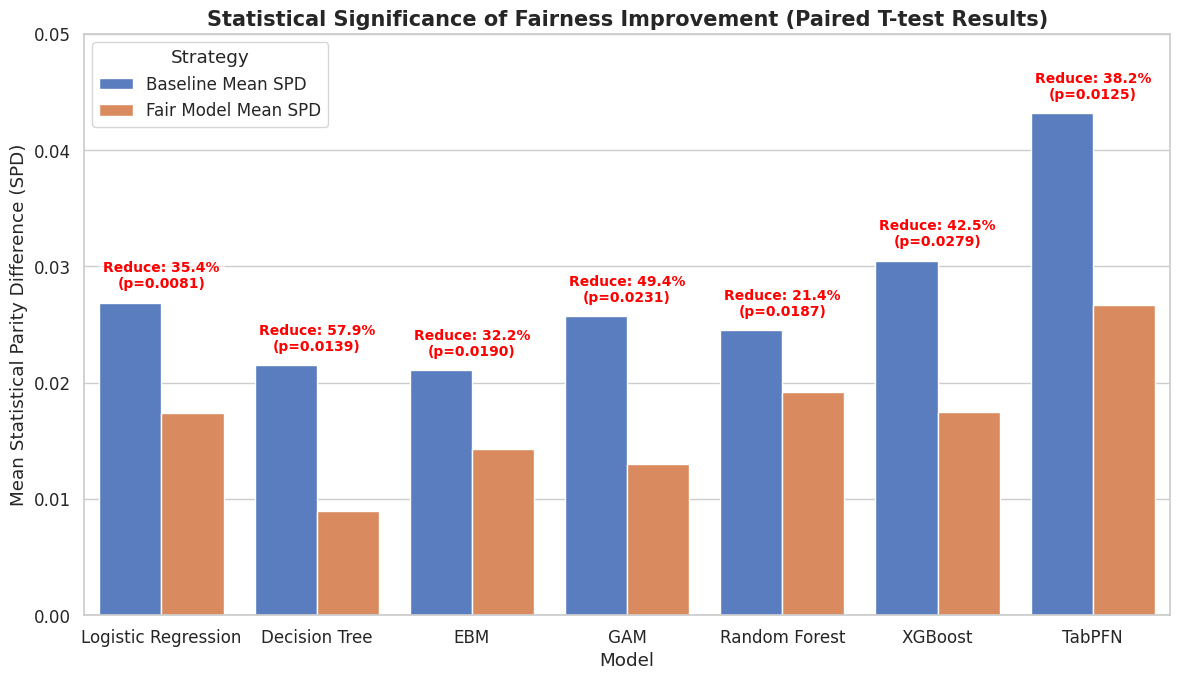

Finish Fairness improvement and statistical significance chart

The visualization chart has been generated and saved to: 'Saved_Results/'


In [ ]:
# Fairness improvement and statistical significance chart
plt.figure(figsize=(12, 7))
# Plotting the change in average SPD
sig_melted = df_sig.melt(id_vars=['Model', 'Bias Reduction', 'P-Value'],
                             value_vars=['Baseline Mean SPD', 'Fair Model Mean SPD'],
                             var_name='Strategy', value_name='Mean SPD')

ax3 = sns.barplot(data=sig_melted, x='Model', y='Mean SPD', hue='Strategy', palette='muted')

# Labeling of reduction and P-value
for i, model in enumerate(df_sig['Model']):
    reduction = df_sig.loc[df_sig['Model'] == model, 'Bias Reduction'].values[0]
    p_val = df_sig.loc[df_sig['Model'] == model, 'P-Value'].values[0]
    y_max = df_sig.loc[df_sig['Model'] == model, 'Baseline Mean SPD'].values[0]

    # Annotation improvement rate
    ax3.text(i, y_max + 0.001, f"Reduce: {reduction}\n(p={p_val:.4f})",
                 ha='center', va='bottom', color='red', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Statistical Significance of Fairness Improvement (Paired T-test Results)', fontsize=15,
              fontweight='bold')
plt.ylabel('Mean Statistical Parity Difference (SPD)')
plt.ylim(0, 0.05)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'Figure_Significance.png'), dpi=300)
plt.show()

print("Finish Fairness improvement and statistical significance chart")
print(f"\nThe visualization chart has been generated and saved to: '{RESULTS_DIR}/'")